In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=115a1f03a0855c9a5874a5fd47cc7b34bd02656cf4a12e3b9c74c4cccd026440
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
# === 0) 環境與資料 ===
import numpy as np
import pandas as pd

# ISLP：Python 版 ISL 的資料與工具
# pip install ISLP statsmodels scikit-learn
from ISLP import load_data

import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 載入 Weekly 資料
Weekly = load_data('Weekly')  # 欄位包含: Year, Today, Direction(Up/Down), Lag1..Lag5, Volume
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


               Year         Lag1         Lag2         Lag3         Lag4  \
count   1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean    2000.048669     0.150585     0.151079     0.147205     0.145818   
std        6.033182     2.357013     2.357254     2.360502     2.360279   
min     1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%     1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%     2000.000000     0.241000     0.241000     0.241000     0.238000   
75%     2005.000000     1.405000     1.409000     1.409000     1.409000   
max     2010.000000    12.026000    12.026000    12.026000    12.026000   

               Lag5       Volume        Today Direction  
count   1089.000000  1089.000000  1089.00

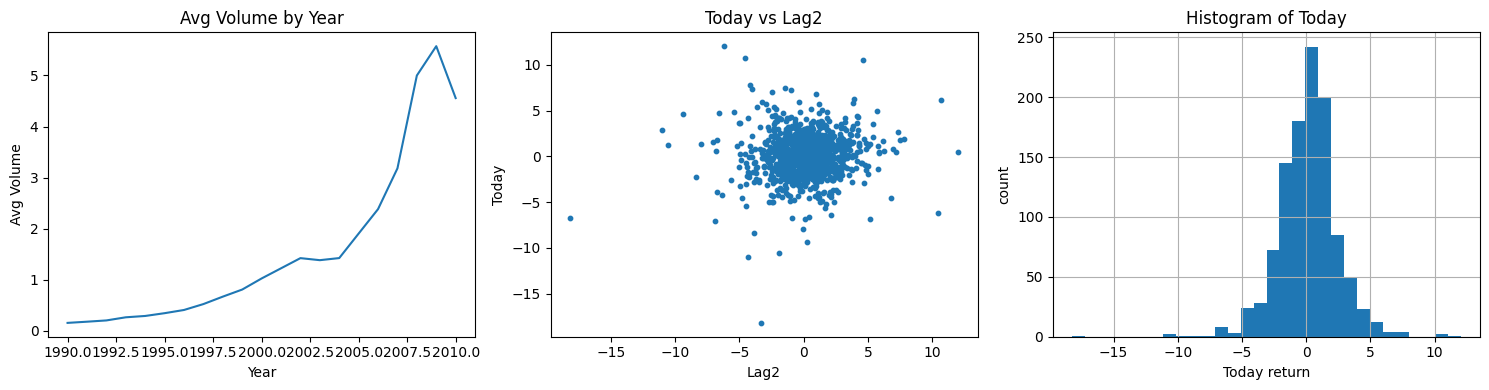

In [ ]:
# 數值摘要
print(Weekly.describe(include='all'))

# 類別分佈（Direction）
print('\nDirection counts:\n', Weekly['Direction'].value_counts())

# 相關係數（只看數值欄位）
print('\nCorrelation matrix (numeric columns):\n', Weekly.select_dtypes(np.number).corr())

# 圖形摘要（幾個最有用的）
fig, axes = plt.subplots(1, 3, figsize=(15,4))
Weekly.groupby('Year')['Volume'].mean().plot(ax=axes[0], title='Avg Volume by Year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Avg Volume')

axes[1].scatter(Weekly['Lag2'], Weekly['Today'], s=10)
axes[1].set_title('Today vs Lag2'); axes[1].set_xlabel('Lag2'); axes[1].set_ylabel('Today')

Weekly['Today'].hist(bins=30, ax=axes[2])
axes[2].set_title('Histogram of Today'); axes[2].set_xlabel('Today return'); axes[2].set_ylabel('count')
plt.tight_layout(); plt.show()

In [ ]:
Weekly['Direction_bin'] = (Weekly['Direction'] == 'Up').astype(int)

logit_full = smf.logit("Direction_bin ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume", data=Weekly).fit()
print(logit_full.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_bin   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        18:57:26   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

In [ ]:
proba_full = logit_full.predict(Weekly)
pred_full = (proba_full >= 0.5).astype(int)

cm_full = confusion_matrix(Weekly['Direction_bin'], pred_full)
acc_full = accuracy_score(Weekly['Direction_bin'], pred_full)

print("Confusion Matrix (Full):\n", cm_full)
print("Accuracy (Full):", acc_full)
print(classification_report(Weekly['Direction_bin'], pred_full, target_names=['Down','Up']))


Confusion Matrix (Full):
 [[ 54 430]
 [ 48 557]]
Accuracy (Full): 0.5610651974288338
              precision    recall  f1-score   support

        Down       0.53      0.11      0.18       484
          Up       0.56      0.92      0.70       605

    accuracy                           0.56      1089
   macro avg       0.55      0.52      0.44      1089
weighted avg       0.55      0.56      0.47      1089



In [ ]:
train = Weekly['Year'] <= 2008
test  = Weekly['Year'] >= 2009

logit_lag2 = smf.logit("Direction_bin ~ Lag2", data=Weekly[train]).fit()
print(logit_lag2.summary())

proba_te = logit_lag2.predict(Weekly[test])
pred_te = (proba_te >= 0.5).astype(int)
cm_logit = confusion_matrix(Weekly.loc[test, 'Direction_bin'], pred_te)
acc_logit = accuracy_score(Weekly.loc[test, 'Direction_bin'], pred_te)

print("Logit(Lag2) Test Confusion Matrix:\n", cm_logit)
print("Logit(Lag2) Test Accuracy:", acc_logit)

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_bin   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        18:57:30   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.

In [ ]:
X_tr = Weekly.loc[train, ['Lag2']].values
y_tr = Weekly.loc[train, 'Direction_bin'].values
X_te = Weekly.loc[test,  ['Lag2']].values
y_te = Weekly.loc[test,  'Direction_bin'].values

lda = LinearDiscriminantAnalysis().fit(X_tr, y_tr)
pred_lda = lda.predict(X_te)
cm_lda = confusion_matrix(y_te, pred_lda)
acc_lda = accuracy_score(y_te, pred_lda)
print("LDA(Lag2) Test Confusion Matrix:\n", cm_lda)
print("LDA(Lag2) Test Accuracy:", acc_lda)

LDA(Lag2) Test Confusion Matrix:
 [[ 9 34]
 [ 5 56]]
LDA(Lag2) Test Accuracy: 0.625


In [ ]:
qda = QuadraticDiscriminantAnalysis().fit(X_tr, y_tr)
pred_qda = qda.predict(X_te)
cm_qda = confusion_matrix(y_te, pred_qda)
acc_qda = accuracy_score(y_te, pred_qda)
print("QDA(Lag2) Test Confusion Matrix:\n", cm_qda)
print("QDA(Lag2) Test Accuracy:", acc_qda)

QDA(Lag2) Test Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
QDA(Lag2) Test Accuracy: 0.5865384615384616


In [ ]:
knn1 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1))
knn1.fit(X_tr, y_tr)
pred_knn1 = knn1.predict(X_te)
cm_knn1 = confusion_matrix(y_te, pred_knn1)
acc_knn1 = accuracy_score(y_te, pred_knn1)
print("KNN(k=1, Lag2) Test Confusion Matrix:\n", cm_knn1)
print("KNN(k=1, Lag2) Test Accuracy:", acc_knn1)

KNN(k=1, Lag2) Test Confusion Matrix:
 [[22 21]
 [32 29]]
KNN(k=1, Lag2) Test Accuracy: 0.49038461538461536


In [ ]:
nb = GaussianNB().fit(X_tr, y_tr)
pred_nb = nb.predict(X_te)
cm_nb = confusion_matrix(y_te, pred_nb)
acc_nb = accuracy_score(y_te, pred_nb)
print("Naive Bayes(Lag2) Test Confusion Matrix:\n", cm_nb)
print("Naive Bayes(Lag2) Test Accuracy:", acc_nb)

Naive Bayes(Lag2) Test Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Naive Bayes(Lag2) Test Accuracy: 0.5865384615384616


In [ ]:
results = {
    'Logit(Lag2)': acc_logit,
    'LDA(Lag2)': acc_lda,
    'QDA(Lag2)': acc_qda,
    'KNN(k=1, Lag2)': acc_knn1,
    'NaiveBayes(Lag2)': acc_nb
}
print("Test Accuracies (2009–2010):")
for k,v in results.items():
    print(f"{k:16s} : {v:.4f}")

best_model = max(results, key=results.get)
print("\nBest on held-out (2009–2010):", best_model, "acc =", results[best_model])

Test Accuracies (2009–2010):
Logit(Lag2)      : 0.6250
LDA(Lag2)        : 0.6250
QDA(Lag2)        : 0.5865
KNN(k=1, Lag2)   : 0.4904
NaiveBayes(Lag2) : 0.5865

Best on held-out (2009–2010): Logit(Lag2) acc = 0.625


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, accuracy_score

# 切分訓練/測試集 (1990–2008) vs (2009–2010)
train = Weekly['Year'] <= 2008
test  = Weekly['Year'] >= 2009
y_tr  = Weekly.loc[train, 'Direction_bin'].values
y_te  = Weekly.loc[test, 'Direction_bin'].values

# 各種特徵組合
X1_tr = Weekly.loc[train, ['Lag2']].values
X1_te = Weekly.loc[test,  ['Lag2']].values

X2_tr = Weekly.loc[train, ['Lag2', 'Volume']].values
X2_te = Weekly.loc[test,  ['Lag2', 'Volume']].values

# 加入多項式特徵（Lag1, Lag2, Volume 二次項與交互作用）
poly = PolynomialFeatures(degree=2, include_bias=False)
X3_tr = poly.fit_transform(Weekly.loc[train, ['Lag1','Lag2','Volume']].values)
X3_te = poly.transform(Weekly.loc[test,  ['Lag1','Lag2','Volume']].values)

results = []

# Helper function
def record_result(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    results.append((name, acc, cm))

# Logistic Regression
log1 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log1.fit(X1_tr, y_tr)
record_result("Logit(Lag2)", y_te, log1.predict(X1_te))

log2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log2.fit(X2_tr, y_tr)
record_result("Logit(Lag2+Vol)", y_te, log2.predict(X2_te))

log3 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log3.fit(X3_tr, y_tr)
record_result("Logit(Poly2 Lag1,Lag2,Vol)", y_te, log3.predict(X3_te))

# LDA
lda1 = LinearDiscriminantAnalysis().fit(X1_tr, y_tr)
record_result("LDA(Lag2)", y_te, lda1.predict(X1_te))

lda2 = LinearDiscriminantAnalysis().fit(X2_tr, y_tr)
record_result("LDA(Lag2+Vol)", y_te, lda2.predict(X2_te))

lda3 = LinearDiscriminantAnalysis().fit(X3_tr, y_tr)
record_result("LDA(Poly2 Lag1,Lag2,Vol)", y_te, lda3.predict(X3_te))

# QDA
qda1 = QuadraticDiscriminantAnalysis().fit(X1_tr, y_tr)
record_result("QDA(Lag2)", y_te, qda1.predict(X1_te))

qda2 = QuadraticDiscriminantAnalysis().fit(X2_tr, y_tr)
record_result("QDA(Lag2+Vol)", y_te, qda2.predict(X2_te))

qda3 = QuadraticDiscriminantAnalysis().fit(X3_tr, y_tr)
record_result("QDA(Poly2 Lag1,Lag2,Vol)", y_te, qda3.predict(X3_te))

# Naive Bayes
nb1 = GaussianNB().fit(X1_tr, y_tr)
record_result("NaiveBayes(Lag2)", y_te, nb1.predict(X1_te))

nb2 = GaussianNB().fit(X2_tr, y_tr)
record_result("NaiveBayes(Lag2+Vol)", y_te, nb2.predict(X2_te))

# KNN 掃 K 值
for k in [1,3,5,7,9,11,15,21,25,31]:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    knn.fit(X2_tr, y_tr)
    record_result(f"KNN(k={k}, Lag2+Vol)", y_te, knn.predict(X2_te))

# 彙整與輸出
df_res = pd.DataFrame(results, columns=['Model','Accuracy','ConfusionMatrix']).sort_values(by='Accuracy', ascending=False)
print(df_res[['Model','Accuracy']])
best = df_res.iloc[0]
print("\n=== Best Model on Held-out (2009–2010) ===")
print(best['Model'])
print("Accuracy:", best['Accuracy'])
print("Confusion Matrix:\n", best['ConfusionMatrix'])

                         Model  Accuracy
0                  Logit(Lag2)  0.625000
3                    LDA(Lag2)  0.625000
15          KNN(k=9, Lag2+Vol)  0.596154
6                    QDA(Lag2)  0.586538
9             NaiveBayes(Lag2)  0.586538
16         KNN(k=11, Lag2+Vol)  0.548077
13          KNN(k=5, Lag2+Vol)  0.548077
1              Logit(Lag2+Vol)  0.538462
4                LDA(Lag2+Vol)  0.538462
14          KNN(k=7, Lag2+Vol)  0.538462
18         KNN(k=21, Lag2+Vol)  0.519231
12          KNN(k=3, Lag2+Vol)  0.509615
11          KNN(k=1, Lag2+Vol)  0.509615
19         KNN(k=25, Lag2+Vol)  0.490385
17         KNN(k=15, Lag2+Vol)  0.490385
5     LDA(Poly2 Lag1,Lag2,Vol)  0.490385
8     QDA(Poly2 Lag1,Lag2,Vol)  0.480769
7                QDA(Lag2+Vol)  0.471154
10        NaiveBayes(Lag2+Vol)  0.461538
20         KNN(k=31, Lag2+Vol)  0.461538
2   Logit(Poly2 Lag1,Lag2,Vol)  0.451923

=== Best Model on Held-out (2009–2010) ===
Logit(Lag2)
Accuracy: 0.625
Confusion Matrix:
 [[ 9 34